# ECDC COVID-19 Dataset Analysis

## INTRODUCTION
The COVID-19 pandemic, caused by the SARS-CoV-2 virus, has resulted in an unprecedented global health crisis.
Governments, public health institutions, and researchers have been gathering massive datasets to track the spread of the virus. One such dataset is the ECDC COVID-19 dataset from Kaggle, which provides a comprehensive overview of confirmed cases and deaths from various countries across different dates.
This dataset includes daily records of confirmed cases and deaths reported globally, along with key geographical identifiers. By analyzing this dataset, we can derive insights about the spread of COVID-19 across different countries and territories, the severity of outbreaks, and possible trends or correlations.

## OBJECTIVE
The goal of this project is to:
* Analyze the daily trends of COVID-19 cases and deaths.
* Explore variations in cases and deaths across different countries and regions.

## Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [2]:
df=pd.read_csv('ECDC_COVID_19.csv')

In [3]:
df

,dateRep,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2018
0,2020-04-08,8,4,2020,30,4,Afghanistan,AF,AFG,37172386.0
1,2020-04-07,7,4,2020,38,0,Afghanistan,AF,AFG,37172386.0
2,2020-04-06,6,4,2020,29,2,Afghanistan,AF,AFG,37172386.0
3,2020-04-05,5,4,2020,35,1,Afghanistan,AF,AFG,37172386.0
4,2020-04-04,4,4,2020,0,0,Afghanistan,AF,AFG,37172386.0
...,...,...,...,...,...,...,...,...,...,...
9508,2020-03-25,25,3,2020,0,0,Zimbabwe,ZW,ZWE,14439018.0
9509,2020-03-24,24,3,2020,0,1,Zimbabwe,ZW,ZWE,14439018.0
9510,2020-03-23,23,3,2020,0,0,Zimbabwe,ZW,ZWE,14439018.0
9511,2020-03-22,22,3,2020,1,0,Zimbabwe,ZW,ZWE,14439018.0


In [4]:
df.duplicated().sum()

0

### There are null values in 3 columns
* geoId = 25
* countriesAndTerritoryCode = 189
* popData2018 = 143

In [5]:
df.isnull().sum()

dateRep                      0
day                          0
month                        0
year                         0
cases                        0
deaths                       0
countriesAndTerritories      0
geoId                       25
countryterritoryCode       189
popData2018                143
dtype: int64

### fill null values in the column popData2018 using medium()

In [6]:
df['popData2018'].fillna(df['popData2018'].median(),inplace=True)

### checking null values and fill in the column geoId

In [7]:
geoid_null=df[df['geoId'].isnull()].reset_index(drop=True)

In [8]:
geoid_null

,dateRep,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2018
0,2020-04-08,8,4,2020,0,0,Namibia,NaN,NAM,2448255.0
1,2020-04-07,7,4,2020,0,0,Namibia,NaN,NAM,2448255.0
2,2020-04-06,6,4,2020,2,0,Namibia,NaN,NAM,2448255.0
3,2020-04-05,5,4,2020,0,0,Namibia,NaN,NAM,2448255.0
4,2020-04-04,4,4,2020,1,0,Namibia,NaN,NAM,2448255.0
5,2020-04-03,3,4,2020,0,0,Namibia,NaN,NAM,2448255.0
6,2020-04-02,2,4,2020,2,0,Namibia,NaN,NAM,2448255.0
7,2020-04-01,1,4,2020,0,0,Namibia,NaN,NAM,2448255.0
8,2020-03-31,31,3,2020,0,0,Namibia,NaN,NAM,2448255.0
9,2020-03-30,30,3,2020,3,0,Namibia,NaN,NAM,2448255.0


In [9]:
geoid_namibia=df['geoId'][df['countriesAndTerritories']=='Namibia']
geoid_namibia

6047    NaN
6048    NaN
6049    NaN
6050    NaN
6051    NaN
6052    NaN
6053    NaN
6054    NaN
6055    NaN
6056    NaN
6057    NaN
6058    NaN
6059    NaN
6060    NaN
6061    NaN
6062    NaN
6063    NaN
6064    NaN
6065    NaN
6066    NaN
6067    NaN
6068    NaN
6069    NaN
6070    NaN
6071    NaN
Name: geoId, dtype: object

In [10]:
df['geoId'].fillna('NA',inplace=True)

### checking null values and fill in the column countryterritoryCode 

In [11]:
code_null=df[df['countryterritoryCode'].isnull()].reset_index(drop=True)

In [12]:
code_null

,dateRep,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2018
0,2020-04-08,8,4,2020,0,0,Anguilla,AI,NaN,10627165.0
1,2020-04-07,7,4,2020,0,0,Anguilla,AI,NaN,10627165.0
2,2020-04-06,6,4,2020,0,0,Anguilla,AI,NaN,10627165.0
3,2020-04-05,5,4,2020,0,0,Anguilla,AI,NaN,10627165.0
4,2020-04-04,4,4,2020,0,0,Anguilla,AI,NaN,10627165.0
...,...,...,...,...,...,...,...,...,...,...
184,2020-04-08,8,4,2020,3,0,Falkland_Islands_(Malvinas),FK,NaN,10627165.0
185,2020-04-07,7,4,2020,0,0,Falkland_Islands_(Malvinas),FK,NaN,10627165.0
186,2020-04-06,6,4,2020,1,0,Falkland_Islands_(Malvinas),FK,NaN,10627165.0
187,2020-04-05,5,4,2020,0,0,Falkland_Islands_(Malvinas),FK,NaN,10627165.0


In [13]:
code_null['countriesAndTerritories'].unique()

array(['Anguilla', 'Bonaire, Saint Eustatius and Saba',
       'Cases_on_an_international_conveyance_Japan', 'Czechia',
       'Falkland_Islands_(Malvinas)'], dtype=object)

In [14]:
anguilla=df[df['countriesAndTerritories']=='Anguilla']
anguilla

,dateRep,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2018
260,2020-04-08,8,4,2020,0,0,Anguilla,AI,NaN,10627165.0
261,2020-04-07,7,4,2020,0,0,Anguilla,AI,NaN,10627165.0
262,2020-04-06,6,4,2020,0,0,Anguilla,AI,NaN,10627165.0
263,2020-04-05,5,4,2020,0,0,Anguilla,AI,NaN,10627165.0
264,2020-04-04,4,4,2020,0,0,Anguilla,AI,NaN,10627165.0
265,2020-04-03,3,4,2020,1,0,Anguilla,AI,NaN,10627165.0
266,2020-04-02,2,4,2020,0,0,Anguilla,AI,NaN,10627165.0
267,2020-04-01,1,4,2020,0,0,Anguilla,AI,NaN,10627165.0
268,2020-03-31,31,3,2020,0,0,Anguilla,AI,NaN,10627165.0
269,2020-03-30,30,3,2020,0,0,Anguilla,AI,NaN,10627165.0


In [15]:
df.loc[260:272].fillna('AIA',inplace=True)

In [16]:
df[df['countriesAndTerritories']=='Anguilla']

,dateRep,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2018
260,2020-04-08,8,4,2020,0,0,Anguilla,AI,AIA,10627165.0
261,2020-04-07,7,4,2020,0,0,Anguilla,AI,AIA,10627165.0
262,2020-04-06,6,4,2020,0,0,Anguilla,AI,AIA,10627165.0
263,2020-04-05,5,4,2020,0,0,Anguilla,AI,AIA,10627165.0
264,2020-04-04,4,4,2020,0,0,Anguilla,AI,AIA,10627165.0
265,2020-04-03,3,4,2020,1,0,Anguilla,AI,AIA,10627165.0
266,2020-04-02,2,4,2020,0,0,Anguilla,AI,AIA,10627165.0
267,2020-04-01,1,4,2020,0,0,Anguilla,AI,AIA,10627165.0
268,2020-03-31,31,3,2020,0,0,Anguilla,AI,AIA,10627165.0
269,2020-03-30,30,3,2020,0,0,Anguilla,AI,AIA,10627165.0


In [17]:
BSES=df['countryterritoryCode'][df['countriesAndTerritories']=='Bonaire, Saint Eustatius and Saba']

In [18]:
BSES

1199    NaN
1200    NaN
1201    NaN
1202    NaN
1203    NaN
1204    NaN
1205    NaN
Name: countryterritoryCode, dtype: object

In [19]:
df.loc[1199:1205].fillna('BES',inplace=True)

In [20]:
df[df['countriesAndTerritories']=='Bonaire, Saint Eustatius and Saba']

,dateRep,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2018
1199,2020-04-08,8,4,2020,0,0,"Bonaire, Saint Eustatius and Saba",BQ,BES,10627165.0
1200,2020-04-07,7,4,2020,0,0,"Bonaire, Saint Eustatius and Saba",BQ,BES,10627165.0
1201,2020-04-06,6,4,2020,0,0,"Bonaire, Saint Eustatius and Saba",BQ,BES,10627165.0
1202,2020-04-05,5,4,2020,0,0,"Bonaire, Saint Eustatius and Saba",BQ,BES,10627165.0
1203,2020-04-04,4,4,2020,0,0,"Bonaire, Saint Eustatius and Saba",BQ,BES,10627165.0
1204,2020-04-03,3,4,2020,0,0,"Bonaire, Saint Eustatius and Saba",BQ,BES,10627165.0
1205,2020-04-02,2,4,2020,2,0,"Bonaire, Saint Eustatius and Saba",BQ,BES,10627165.0


In [21]:
CICJ=df['countryterritoryCode'][df['countriesAndTerritories']=='Cases_on_an_international_conveyance_Japan']

In [22]:
CICJ

1682    NaN
1683    NaN
1684    NaN
1685    NaN
1686    NaN
       ... 
1741    NaN
1742    NaN
1743    NaN
1744    NaN
1745    NaN
Name: countryterritoryCode, Length: 64, dtype: object

In [23]:
df.loc[1682:1745].fillna('IC Japan',inplace=True)

In [24]:
df[df['countriesAndTerritories']=='Cases_on_an_international_conveyance_Japan']

,dateRep,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2018
1682,2020-03-10,10,3,2020,-9,1,Cases_on_an_international_conveyance_Japan,JPG11668,IC Japan,3000.0
1683,2020-03-02,2,3,2020,0,0,Cases_on_an_international_conveyance_Japan,JPG11668,IC Japan,3000.0
1684,2020-03-01,1,3,2020,0,0,Cases_on_an_international_conveyance_Japan,JPG11668,IC Japan,3000.0
1685,2020-02-29,29,2,2020,0,2,Cases_on_an_international_conveyance_Japan,JPG11668,IC Japan,3000.0
1686,2020-02-28,28,2,2020,0,0,Cases_on_an_international_conveyance_Japan,JPG11668,IC Japan,3000.0
...,...,...,...,...,...,...,...,...,...,...
1741,2020-01-04,4,1,2020,0,0,Cases_on_an_international_conveyance_Japan,JPG11668,IC Japan,3000.0
1742,2020-01-03,3,1,2020,0,0,Cases_on_an_international_conveyance_Japan,JPG11668,IC Japan,3000.0
1743,2020-01-02,2,1,2020,0,0,Cases_on_an_international_conveyance_Japan,JPG11668,IC Japan,3000.0
1744,2020-01-01,1,1,2020,0,0,Cases_on_an_international_conveyance_Japan,JPG11668,IC Japan,3000.0


In [25]:
czechia=df['countryterritoryCode'][df['countriesAndTerritories']=='Czechia']

In [26]:
czechia

2222    NaN
2223    NaN
2224    NaN
2225    NaN
2226    NaN
       ... 
2317    NaN
2318    NaN
2319    NaN
2320    NaN
2321    NaN
Name: countryterritoryCode, Length: 100, dtype: object

In [27]:
df.loc[2222:2321].fillna('CZE',inplace=True)

In [28]:
df[df['countriesAndTerritories']=='Czechia']

,dateRep,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2018
2222,2020-04-08,8,4,2020,195,10,Czechia,CZ,CZE,10627165.0
2223,2020-04-07,7,4,2020,235,11,Czechia,CZ,CZE,10627165.0
2224,2020-04-06,6,4,2020,115,8,Czechia,CZ,CZE,10627165.0
2225,2020-04-05,5,4,2020,282,6,Czechia,CZ,CZE,10627165.0
2226,2020-04-04,4,4,2020,332,9,Czechia,CZ,CZE,10627165.0
...,...,...,...,...,...,...,...,...,...,...
2317,2020-01-04,4,1,2020,0,0,Czechia,CZ,CZE,10627165.0
2318,2020-01-03,3,1,2020,0,0,Czechia,CZ,CZE,10627165.0
2319,2020-01-02,2,1,2020,0,0,Czechia,CZ,CZE,10627165.0
2320,2020-01-01,1,1,2020,0,0,Czechia,CZ,CZE,10627165.0


In [29]:
FIM=df['countryterritoryCode'][df['countriesAndTerritories']=='Falkland_Islands_(Malvinas)']

In [30]:
FIM

2979    NaN
2980    NaN
2981    NaN
2982    NaN
2983    NaN
Name: countryterritoryCode, dtype: object

In [31]:
df.loc[2979:2983].fillna('FLK',inplace=True)

In [32]:
df[df['countriesAndTerritories']=='Falkland_Islands_(Malvinas)']

,dateRep,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2018
2979,2020-04-08,8,4,2020,3,0,Falkland_Islands_(Malvinas),FK,FLK,10627165.0
2980,2020-04-07,7,4,2020,0,0,Falkland_Islands_(Malvinas),FK,FLK,10627165.0
2981,2020-04-06,6,4,2020,1,0,Falkland_Islands_(Malvinas),FK,FLK,10627165.0
2982,2020-04-05,5,4,2020,0,0,Falkland_Islands_(Malvinas),FK,FLK,10627165.0
2983,2020-04-04,4,4,2020,1,0,Falkland_Islands_(Malvinas),FK,FLK,10627165.0


In [33]:
df.isna().sum()

dateRep                    0
day                        0
month                      0
year                       0
cases                      0
deaths                     0
countriesAndTerritories    0
geoId                      0
countryterritoryCode       0
popData2018                0
dtype: int64

## Extracting day and month names

In [34]:
df['dateRep']=pd.to_datetime(df['dateRep'])

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9513 entries, 0 to 9512
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   dateRep                  9513 non-null   datetime64[ns]
 1   day                      9513 non-null   int64         
 2   month                    9513 non-null   int64         
 3   year                     9513 non-null   int64         
 4   cases                    9513 non-null   int64         
 5   deaths                   9513 non-null   int64         
 6   countriesAndTerritories  9513 non-null   object        
 7   geoId                    9513 non-null   object        
 8   countryterritoryCode     9513 non-null   object        
 9   popData2018              9513 non-null   float64       
dtypes: datetime64[ns](1), float64(1), int64(5), object(3)
memory usage: 743.3+ KB


In [36]:
df['month name']=df['dateRep'].dt.month_name()
df['day name']=df['dateRep'].dt.day_name()

In [37]:
df

,dateRep,day,month,year,cases,deaths,countriesAndTerritories,geoId,countryterritoryCode,popData2018,month name,day name
0,2020-04-08,8,4,2020,30,4,Afghanistan,AF,AFG,37172386.0,April,Wednesday
1,2020-04-07,7,4,2020,38,0,Afghanistan,AF,AFG,37172386.0,April,Tuesday
2,2020-04-06,6,4,2020,29,2,Afghanistan,AF,AFG,37172386.0,April,Monday
3,2020-04-05,5,4,2020,35,1,Afghanistan,AF,AFG,37172386.0,April,Sunday
4,2020-04-04,4,4,2020,0,0,Afghanistan,AF,AFG,37172386.0,April,Saturday
...,...,...,...,...,...,...,...,...,...,...,...,...
9508,2020-03-25,25,3,2020,0,0,Zimbabwe,ZW,ZWE,14439018.0,March,Wednesday
9509,2020-03-24,24,3,2020,0,1,Zimbabwe,ZW,ZWE,14439018.0,March,Tuesday
9510,2020-03-23,23,3,2020,0,0,Zimbabwe,ZW,ZWE,14439018.0,March,Monday
9511,2020-03-22,22,3,2020,1,0,Zimbabwe,ZW,ZWE,14439018.0,March,Sunday


In [38]:
df.columns

Index(['dateRep', 'day', 'month', 'year', 'cases', 'deaths',
       'countriesAndTerritories', 'geoId', 'countryterritoryCode',
       'popData2018', 'month name', 'day name'],
      dtype='object')

# Top and Least Countries Reported Covid 19 Cases

In [39]:
country_cases_top=df.groupby('countriesAndTerritories')['cases'].sum().reset_index().sort_values(ascending=False,by='cases').head(10).reset_index(drop=True)
country_cases_top

,countriesAndTerritories,cases
0,United_States_of_America,398809
1,Spain,140510
2,Italy,135586
3,Germany,103228
4,China,82784
5,France,78167
6,Iran,62589
7,United_Kingdom,55242
8,Turkey,34109
9,Belgium,22194


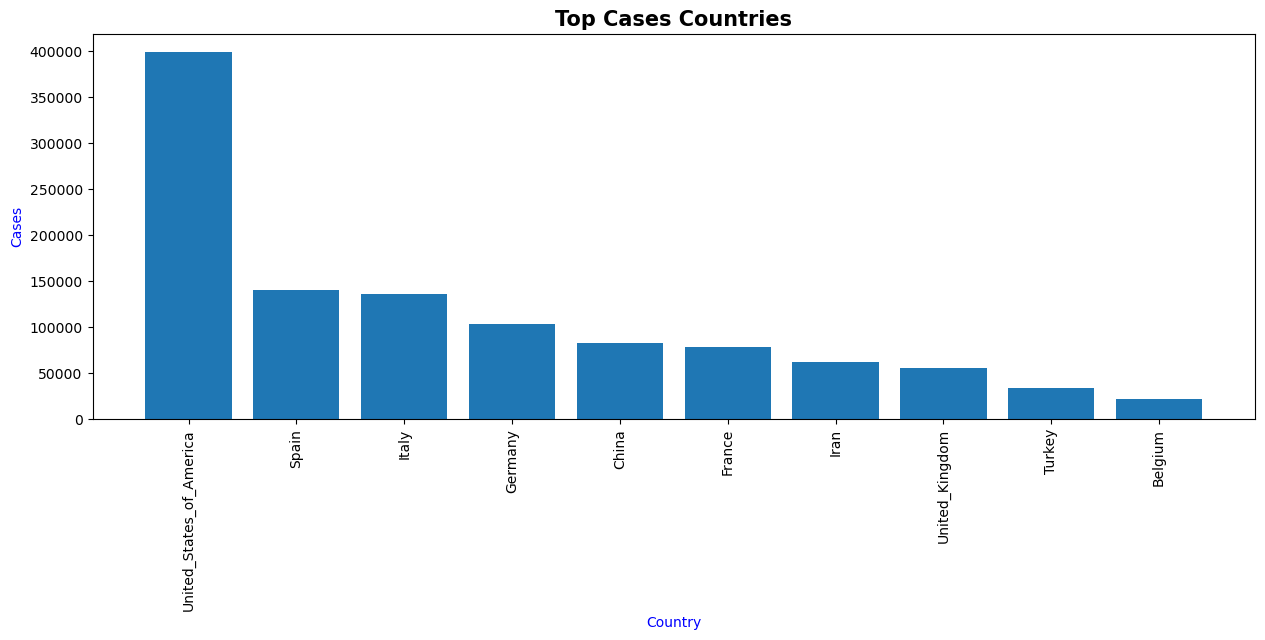

In [40]:
plt.figure(figsize=(15,5))
plt.bar(country_cases_top['countriesAndTerritories'],country_cases_top['cases'])
plt.title('Top Cases Countries',fontsize=15,fontweight='bold')
plt.xlabel('Country',color='b')
plt.ylabel('Cases',color='b')
plt.xticks(rotation=90)
plt.show()

In [41]:
country_cases_least=df.groupby('countriesAndTerritories')['cases'].sum().reset_index().sort_values(ascending=True,by='cases').head(10).reset_index(drop=True)
country_cases_least

,countriesAndTerritories,cases
0,South_Sudan,1
1,Timor_Leste,1
2,"Bonaire, Saint Eustatius and Saba",2
3,Papua_New_Guinea,2
4,British_Virgin_Islands,3
5,Anguilla,3
6,Burundi,3
7,Gambia,4
8,Falkland_Islands_(Malvinas),5
9,Bhutan,5


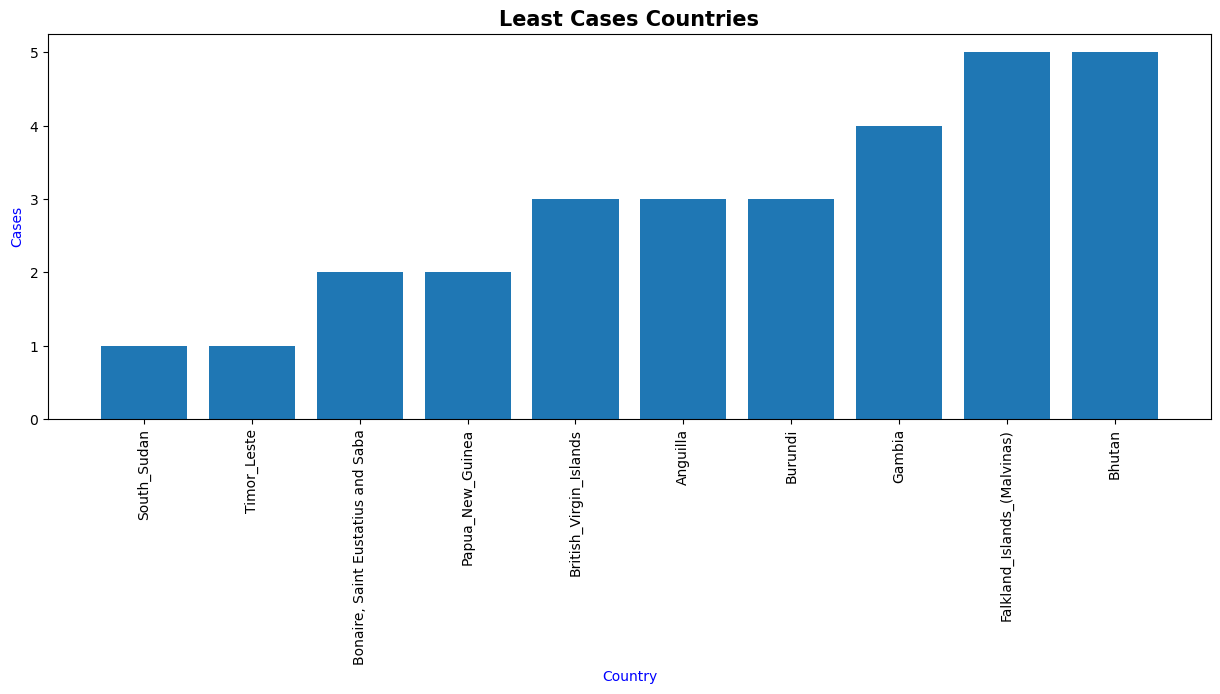

In [42]:
plt.figure(figsize=(15,5))
plt.bar(country_cases_least['countriesAndTerritories'],country_cases_least['cases'])
plt.title('Least Cases Countries',fontsize=15,fontweight='bold')
plt.xlabel('Country',color='b')
plt.ylabel('Cases',color='b')
plt.xticks(rotation=90)
plt.show()

# Top and Least Countries by Deaths

In [43]:
country_deaths_top=df.groupby('countriesAndTerritories')['deaths'].sum().reset_index().sort_values(ascending=False,by='deaths').head(10).reset_index(drop=True)
country_deaths_top

,countriesAndTerritories,deaths
0,Italy,17129
1,Spain,13798
2,United_States_of_America,12895
3,France,10328
4,United_Kingdom,6159
5,Iran,3872
6,China,3337
7,Netherlands,2101
8,Belgium,2035
9,Germany,1861


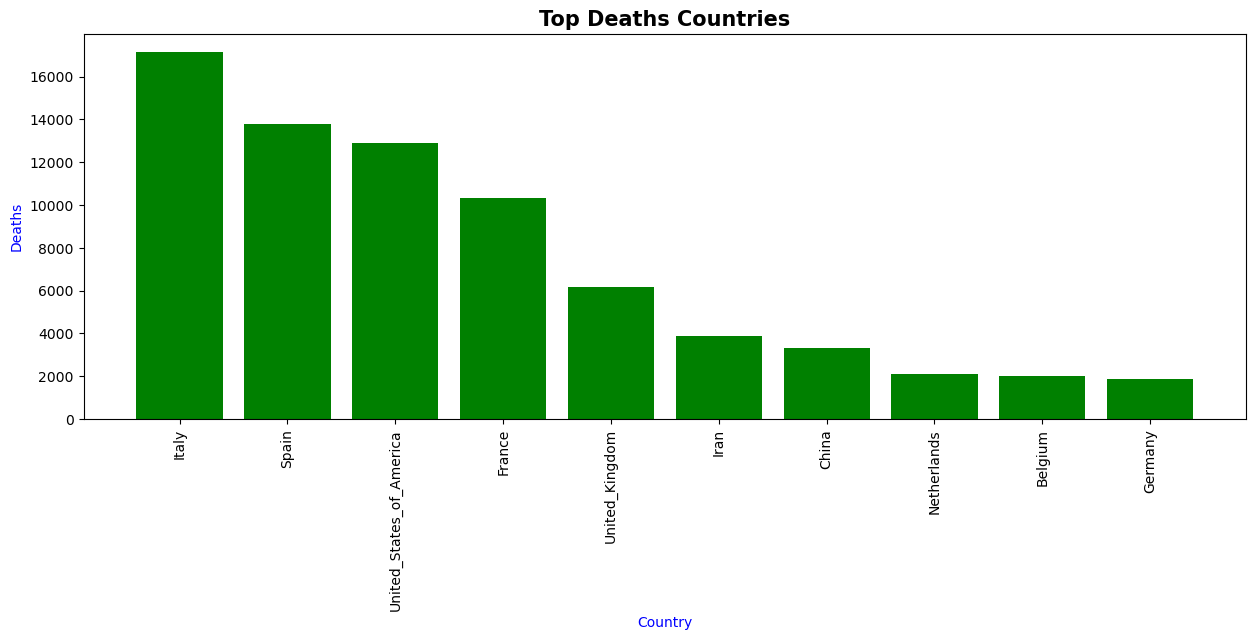

In [44]:
plt.figure(figsize=(15,5))
plt.bar(country_deaths_top['countriesAndTerritories'],country_deaths_top['deaths'],color='g')
plt.title('Top Deaths Countries',fontsize=15,fontweight='bold')
plt.xlabel('Country',color='b')
plt.ylabel('Deaths',color='b')
plt.xticks(rotation=90)
plt.show()

In [45]:
country_deaths_least=df.groupby('countriesAndTerritories')['deaths'].sum().reset_index().sort_values(ascending=True,by='deaths').head(90).reset_index(drop=True)
country_deaths_least

,countriesAndTerritories,deaths
0,British_Virgin_Islands,0
1,Saint_Vincent_and_the_Grenadines,0
2,Saint_Lucia,0
3,Burundi,0
4,Cambodia,0
...,...,...
85,Costa_Rica,2
86,Bermuda,2
87,Togo,3
88,Jamaica,3


In [46]:
df.columns

Index(['dateRep', 'day', 'month', 'year', 'cases', 'deaths',
       'countriesAndTerritories', 'geoId', 'countryterritoryCode',
       'popData2018', 'month name', 'day name'],
      dtype='object')

# Top Cases and Deaths Months

In [47]:
month_cases=df.groupby('month name')['cases'].sum().reset_index().sort_values(ascending=False,by='cases').reset_index(drop=True)
month_cases

,month name,cases
0,March,691930
1,April,614757
2,February,75377
3,January,9799
4,December,27


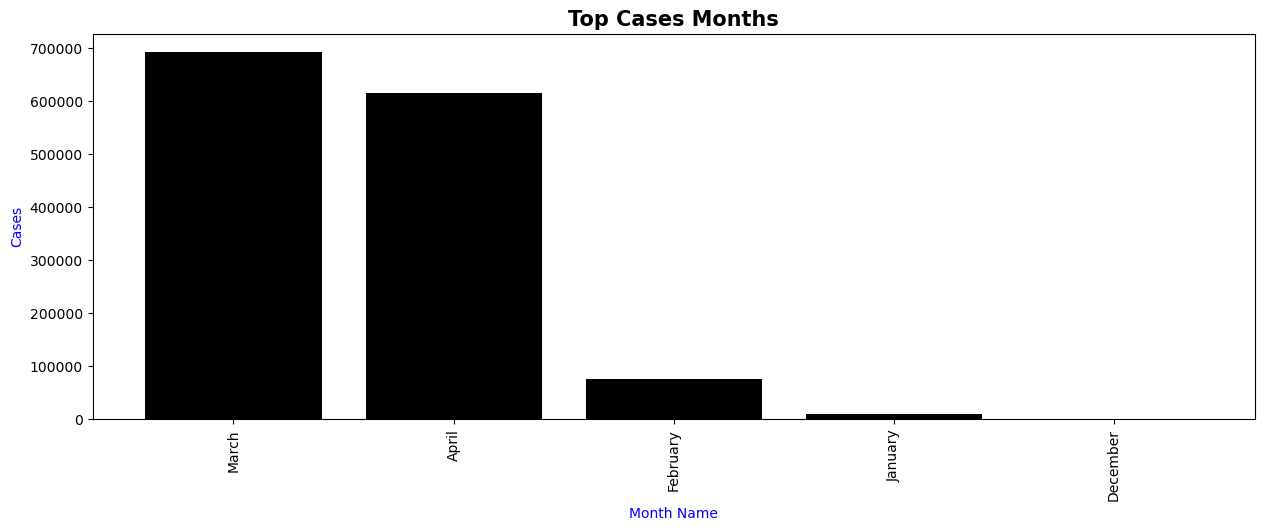

In [48]:
plt.figure(figsize=(15,5))
plt.bar(month_cases['month name'],month_cases['cases'],color='black')
plt.title('Top Cases Months',fontsize=15,fontweight='bold')
plt.xlabel('Month Name',color='b')
plt.ylabel('Cases',color='b')
plt.xticks(rotation=90)
plt.show()

In [49]:
month_deaths=df.groupby('month name')['deaths'].sum().reset_index().sort_values(ascending=False,by='deaths').reset_index(drop=True)
month_deaths

,month name,deaths
0,April,44206
1,March,34351
2,February,2708
3,January,213
4,December,0


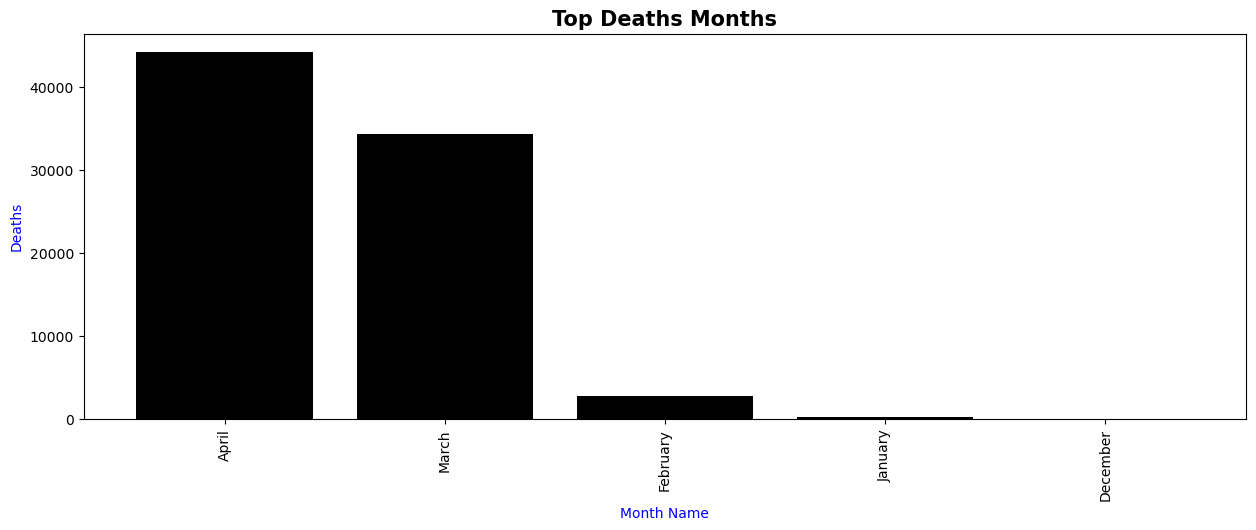

In [50]:
plt.figure(figsize=(15,5))
plt.bar(month_deaths['month name'],month_deaths['deaths'],color='black')
plt.title('Top Deaths Months',fontsize=15,fontweight='bold')
plt.xlabel('Month Name',color='b')
plt.ylabel('Deaths',color='b')
plt.xticks(rotation=90)
plt.show()

# Global Trend of Covid 19 Cases and Deaths Overtime

In [54]:
year_trend=df.groupby('dateRep').sum()[['deaths','cases']].reset_index()
year_trend

,dateRep,deaths,cases
0,2019-12-31,0,27
1,2020-01-01,0,0
2,2020-01-02,0,0
3,2020-01-03,0,17
4,2020-01-04,0,0
...,...,...,...
95,2020-04-04,6586,81714
96,2020-04-05,6115,86713
97,2020-04-06,4655,71232
98,2020-04-07,5137,71392


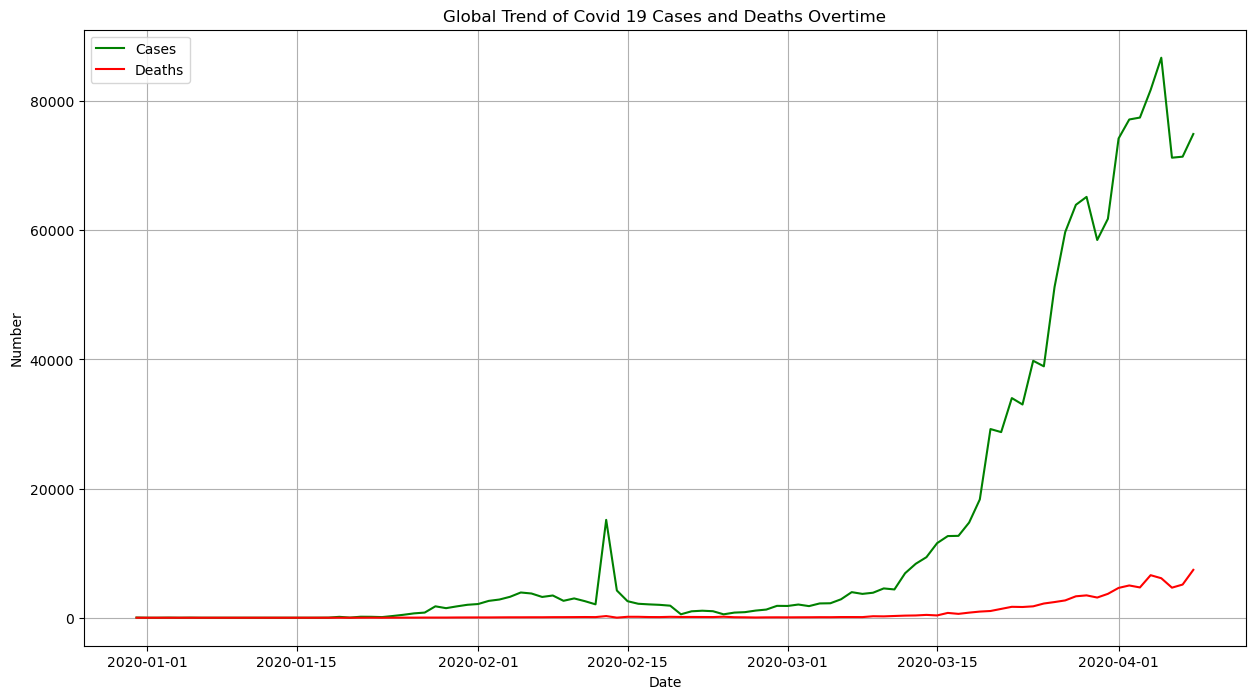

In [57]:
plt.figure(figsize=(15,8))
plt.plot(year_trend['dateRep'],year_trend['cases'],label='Cases',color='green')
plt.plot(year_trend['dateRep'],year_trend['deaths'],label='Deaths',color='red')
plt.title('Global Trend of Covid 19 Cases and Deaths Overtime')
plt.xlabel('Date')
plt.ylabel('Number')
plt.legend()
plt.grid(True)
plt.show()

# Suggestions
* Strengthen Health Systems: Countries with consistently high cases need better healthcare infrastructure to manage ongoing cases and possible future waves.
* Prepare for Surges: Countries that showed rapid spikes in cases should have systems in place for early detection and rapid response to control outbreaks.
* Localized Policies: Countries with high death rates relative to cases may benefit from targeted health interventions, such as prioritizing vaccinations for vulnerable groups.

# Conclusion
The ECDC COVID-19 dataset reveals significant trends in the global spread of COVID-19. This analysis provides valuable insights into the countries most affected by the pandemic and the periods of peak transmission. By leveraging visualizations, we can better understand these patterns and guide effective response measures. Future analyses could delve into specific variants, government responses, and the impact of vaccinations over time.